In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations
from optionanalytics.models.market import MarketData
from optionanalytics.volatility.smile import build_smile

In [2]:
ticker = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,      # Placeholder
)

In [3]:
chain = fetch_option_chain(ticker, expiry)

clean_chain = clean_option_chain(chain)

clean_chain = filter_price_bound_violations(
    clean_chain,
    market_data,
    valuation_date,
)

smile = build_smile(
    clean_chain,
    market_data,
    valuation_date,
)

In [12]:
df = pd.DataFrame(
    {
        "strike": p.strike,
        "implied_volatility": p.implied_volatility,
        "option_type": p.option_type
    } for p in smile.points
)

df = df.sort_values("strike")

df.head()

,strike,implied_volatility,option_type
55,110.0,1.260817,put
56,115.0,1.026662,put
57,120.0,0.987078,put
58,125.0,1.092946,put
59,130.0,1.244895,put


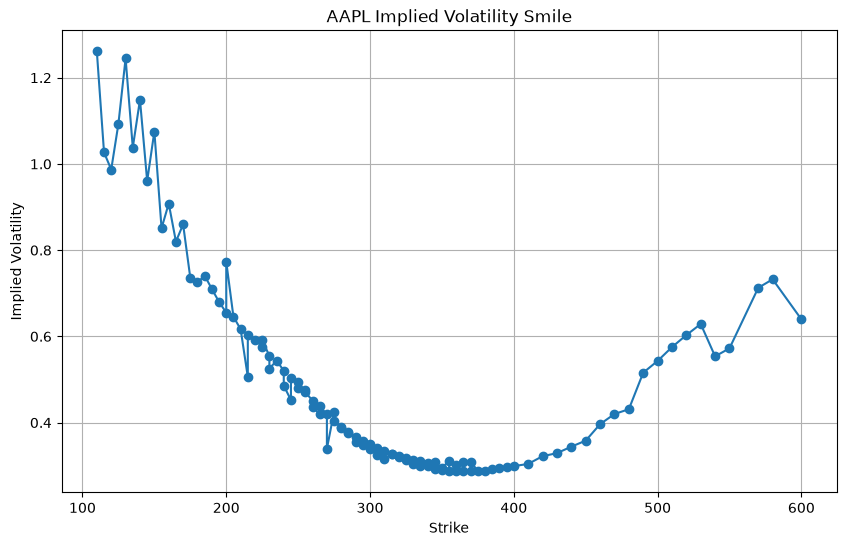

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["strike"],
    df["implied_volatility"],
    marker="o",
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title(f"{ticker} Implied Volatility Smile")
plt.grid(True)

plt.show()

In [14]:
print(df.describe())

           strike  implied_volatility
count  108.000000          108.000000
mean   306.481481            0.502856
std    113.044651            0.237862
min    110.000000            0.286655
25%    228.750000            0.318345
50%    297.500000            0.420130
75%    365.000000            0.603168
max    600.000000            1.260817


In [15]:
df.sort_values("implied_volatility").head()

,strike,implied_volatility,option_type
30,370.0,0.286655,call
29,365.0,0.287367,call
28,360.0,0.287416,call
27,355.0,0.287995,call
32,380.0,0.288303,call


In [16]:
df.sort_values("implied_volatility").tail()

,strike,implied_volatility,option_type
63,150.0,1.075223,put
58,125.0,1.092946,put
61,140.0,1.148831,put
59,130.0,1.244895,put
55,110.0,1.260817,put


In [17]:
market_df = pd.DataFrame(
    {
        "strike": [q.strike for q in clean_chain.quotes],
        "mid_price": [q.mid_price for q in clean_chain.quotes],
        "bid": [q.bid for q in clean_chain.quotes],
        "ask": [q.ask for q in clean_chain.quotes],
    }
)

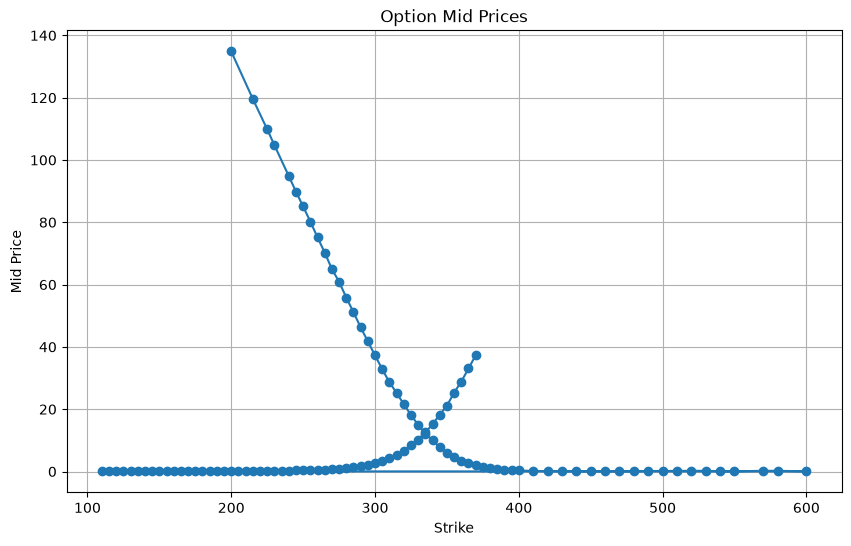

In [18]:
plt.figure(figsize=(10,6))

plt.plot(
    market_df["strike"],
    market_df["mid_price"],
    marker="o",
)

plt.xlabel("Strike")
plt.ylabel("Mid Price")
plt.title("Option Mid Prices")
plt.grid(True)

In [21]:
calls = df[df["option_type"] == "call"]
puts = df[df["option_type"] == "put"]

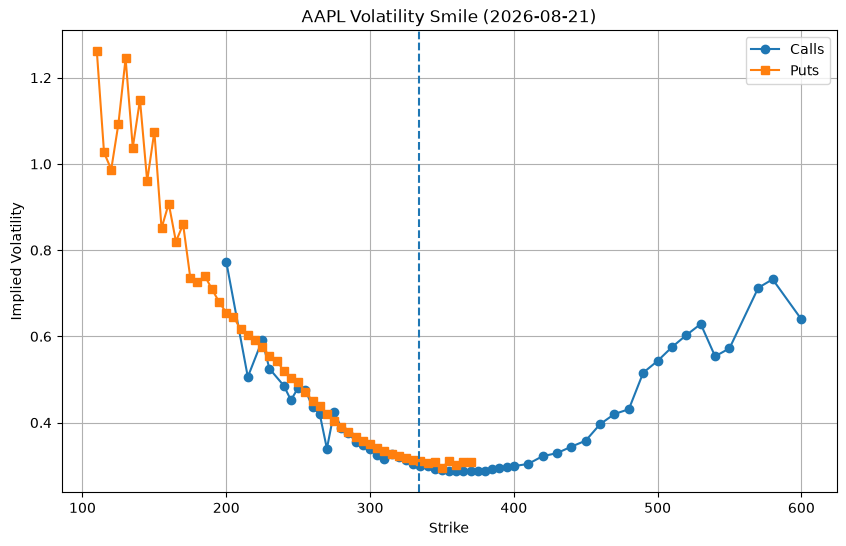

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    calls["strike"],
    calls["implied_volatility"],
    "o-",
    label="Calls",
)

plt.plot(
    puts["strike"],
    puts["implied_volatility"],
    "s-",
    label="Puts",
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title(f"{ticker} Volatility Smile ({expiry})")
plt.grid(True)
plt.legend()

plt.axvline(
    market_data.spot,
    linestyle="--",
    label="Spot",
)

plt.show()